# ISM

In [168]:
# RUN IMPORT LIBRARIES
############################################################################################
import numpy as np
import scipy
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import cv2
import tifffile as tiff
# from PIL import Image
import h5py
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit
from skimage.feature import peak_local_max
import pandas as pd

import scipy as sc

import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.FRC_lib as frc
import brighteyes_ism.analysis.Deconv_lib as dec
import brighteyes_ism.analysis.FocusISM_lib as fism
import brighteyes_ism.analysis.Graph_lib as gra
import brighteyes_ism.analysis.Tools_lib as tool
import brighteyes_ism.dataio.mcs as mcs
import brighteyes_ism.analysis.Deconv_lib as dec
import brighteyes_ism.simulation.PSF_sim as sim
# from scipy.ndimage import fourier_shift, shift 
from os import path
import plotly.express as px
from time import time

In [ ]:
file = 'Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8'

# Qdots_37mW_FOV5um_64x64_100rip_5msPixel # fototubo?
# Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8 # QD poco separati, molti analizzati alcuni con ottimi risultati
# Qdots_770nm_34mW_FOV3um_32x32_50rip_5msPixel_ROI7 # giga QD sfotato al centro
# Qdots_770nm_34mW_FOV5um_64x64_30rip_5msPixel_ROI5 # buona QB
# Qdots_770nm_34mW_FOV5um_64x64_50rip_5msPixel_ROI4 # sfocata a causa di movimento QD
# Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6 # sfocata e troppi QD, non analizzata del tutto
# Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2 # veramente ottima
# Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3 # ni

In [170]:
# RUN INPUT
#############################################################################################

#############################################################################################
# FILE IMPORT AND SETUP
############################################################################################

dir = os.getcwd()
filename = path.join(dir,'images','2025 07 07-08 Qdots',file) # input
savename = path.join(dir,'images','output',file) # output

timeSwitch = True #True if i saved the timetraces
spadFormat=7
Nspad = spadFormat**2

index7=[i for i in range(49) if i != 12]
index5=[8,9,10,11,15,16,17,18,19,22,23,24,25,26,29,30,31,32,33,36,37,38,39,40] #Check if 12 is included or not
index3=[16,17,18,23,24,25,30,31,32]
index1=[17,23,24,25,31]


f = h5py.File(filename + '.h5', 'r') # read h5 file

# ----------------- read header

if timeSwitch:
    group = f['Fluctuations']
    print('Opening time data...')
    Endoftime_h5 = group['IsEndOfTimeBin'][()]
    t_bin=group['Time'][()][0]/1000        #micros
    rep = group.attrs['I_Repetitions'][0]      #repetitions  
else:
    group = f['Image']

imgFormat=group.attrs['I_Height'][0]       #pixels
Depth=group.attrs['I_Depth'][0]            #repetitions/z
ImgFoV=group.attrs['I_XSpan[um]'][0]       #micron
pxsizex=group.attrs['I_XPixelSize[nm]'][0]/1000 #micron         
ZSpan=group.attrs['I_ZSpan[um]'][0]        #micron
pxsizez=group.attrs['I_ZPixelSize[nm]'][0]/1000 #micron
Duration=group.attrs['M_Duration[ms]'][0]  #ms
DwellTime=Duration/(Depth*imgFormat**2)    #ms (approximate)
Fingerprint_h5 = group['Fingerprint'][()]

# ---------------- reading SPAD DATA

print('Opening SPAD data...')
data_h5= group['SPAD'][()]
print('Finished opening')
f.close()

# ----------------- display metadata

print('--------------------METADATA:--------------')
print('imgFormat: ',imgFormat,'x',imgFormat,'px')
print('depth (z): ', Depth)
print('FOV: ', ImgFoV,'μm')
print('pixelsize (x-y): ', pxsizex,'μm')
print('pixelsize (z): ', pxsizez,'μm')
print('ZSpan (z-range):', ZSpan,'μm')
print('Duration frame:', Duration,'ms')
print('Dwell time (time per pixel):', DwellTime,'ms')
print('---------------------------------------------')

# ---------------- fixing binning

# Ch,T,X,Y,R,Z
# print('Full data size: ' + str(data_h5.shape[0]))
# print('Total time bins (no channel distinction): ' +str(Endoftime_h5.shape[0]))

endtime=np.asarray(np.where(Endoftime_h5==1))[0,:]       #Cerco gli indici di Endoftime_h5 dove finiscono i pixels
# print('Scan pixels: ' + str(endtime.shape[0]))
# print('\nendtime: '+str(endtime[:10]))
v = np.max(np.diff(endtime))                             #Cerco la durata massima
# print('maximum temporal timetrace length: ' +str(v))                  
overflow = endtime[np.asarray(np.where(np.diff(endtime)==v))[0,:]+1]  #Indici di cut degli elementi in overflow
# print('\nOverflow: ' +str(overflow))
# print('Pixels in overflow: ' + str(overflow.shape[0]))

over_del = np.zeros(((overflow.shape[0]+1)*Nspad)).astype(np.int64)
for j in range(Nspad):
    over_del[(j)*overflow.shape[0]:overflow.shape[0]*(j+1)]= ((overflow*Nspad)+j)

g=np.linspace(0,48,49).astype(int)
if endtime[0]+1==v: 
    over_del[-49:]=((endtime[0]*Nspad)+g)
else:
    over_del=np.delete(over_del, np.linspace(over_del.shape[0]-Nspad, over_del.shape[0]-1).astype(int) , axis=(0))
    
# print('Bin in data_h5 to be removed: ' +str(over_del))

data_crop = np.delete(data_h5, over_del)
del over_del
del endtime
del g
del overflow
# print('\nFinal size of cropped data: ' +str(data_crop.shape[0]))
# print('Expected size: ' +str(Nspad*Depth*rep*imgFormat**2*(v-1)))

if not data_crop.shape[0]==Nspad*Depth*rep*imgFormat**2*(v-1):
    raise 'data error, bin not corresponding'
# print('size cropped == expected size: ', str(data_crop.shape[0]==Nspad*Depth*rep*imgFormat**2*(v-1)))

# ---------------------------- reshaping (z,rep,y,x,y,ch)

z_i, rep_i, y_i, x_i, t_i, ch_i = 0, 1, 2, 3, 4, 5 # indexes of reshaped data

fingerprint_meta = np.reshape(Fingerprint_h5, (spadFormat,spadFormat))
if not timeSwitch:
    data=np.reshape(data_h5,(Depth,1,imgFormat,imgFormat,1,Nspad)) 
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
else:
    data=np.reshape(data_crop, (Depth,rep,imgFormat,imgFormat,v-1,Nspad))
    print('Data format (z,rep,y,x,t,ch) ' +str(data.shape))
    del data_crop
   
# print('\nCumulative Dwell time (approx.): ' + str(DwellTime) +' ms')
# print('FoV [um]: ' + str(ImgFoV))
# if timeSwitch: print('Time binsize [us]: ' +str(t_bin))
# print('Pixel size [um]: ' +str(pxsizex))
del data_h5 # free the memory

#############################################################################################
# FIRST PLOT, all the data is in 'data'
############################################################################################

#############################################################################################
# data initialization
############################################################################################

index7_fix=[i for i in range(48)]
index5_fix=[8,9,10,11,14,15,16,17,18,21,22,23,24,25,28,29,30,31,32,35,36,37,38,39]
index3_fix=[15,16,17,22,23,24,29,30,31]
index1_fix=[16,22,23,24,30]

# datacut = d7 - spad12
datacut = np.sum(np.delete(data, 12,5)[0,:,:,:,:],axis=(0,3))[...] #Remove SPAD 12 -> output (y,x,ch)
d3 = datacut[:,:,index3_fix]
d5 = datacut[:,:,index5_fix]
d1 = datacut[:,:,index1_fix]
d7 = datacut[:,:,index7_fix]

CENTRAL_SPAD = datacut[:, :,23]#.astype(np.uint8)
D7 = d7.sum(axis=(-1))#.astype(np.uint8)
D5 = d5.sum(axis=(-1))#.astype(np.uint8)
D3 = d3.sum(axis=(-1))#.astype(np.uint8)
D1 = d1.sum(axis=(-1))#.astype(np.uint8)

# im = Image.fromarray(CENTRAL_SPAD) # convert to an image

# -------------------- Plot with Plotly

fig = px.imshow(
    CENTRAL_SPAD, 
    color_continuous_scale='hot',
    title='CENTRAL SPAD',
)
fig.update_layout(
    margin=dict(l=30, r=0, t=0, b=0),
    width=400,
    height=400,
    title=dict(
        y=0.95,  # move title closer to plot
        x=0.5,   # keep centered
        xanchor='center',
        yanchor='top'
    )
)

fig.show()

del Endoftime_h5

Opening time data...
Opening SPAD data...
Finished opening
--------------------METADATA:--------------
imgFormat:  64 x 64 px
depth (z):  1
FOV:  4.0 μm
pixelsize (x-y):  0.0625 μm
pixelsize (z):  100.0 μm
ZSpan (z-range): 100.0 μm
Duration frame: 416002.81009 ms
Dwell time (time per pixel): 101.5631860571289 ms
---------------------------------------------
Data format (z,rep,y,x,t,ch) (1, 100, 64, 64, 10, 49)


In [171]:
fig = px.imshow(
    D7, 
    color_continuous_scale='hot',
    title='CENTRAL SPAD',
)
fig.update_layout(
    margin=dict(l=30, r=0, t=0, b=0),
    width=400,
    height=400,
    title=dict(
        y=0.95,  # move title closer to plot
        x=0.5,   # keep centered
        xanchor='center',
        yanchor='top'
    )
)

fig.show()

### RIASSUNTO METADATA:

| **Parameter** | **Description**                             | **Unit**        |
|---------------|---------------------------------------------|-----------------|
| `imgFormat`   | Image format (e.g., 512x512)                | pixels          |
| `Depth`       | Repetitions along the Z-axis                | repetitions / z |
| `ImgFoV`      | Field of view                               | micron          |
| `pxsizex`     | Pixel size (X/Y axis)                       | micron          |
| `ZSpan`       | Z-axis span (total depth range)             | micron          |
| `pxsizez`     | Pixel size along Z-axis                     | micron          |
| `Duration`    | Time per pixel (e.g., 500 µs)               | ms              |
| `DwellTime`   | Minimum time unit (approximate)             | ms              |


# Image reconstruction (ISM)

The available d3s are: 

data [z,r,y,x,t,ch] <br> d3, d5, d1 [y,x,t,ch] <br>datacut [y,x,t,ch] (- spad 12)

|  0 |  1 |  2 |  3 |  4 |  5 |  6 |   →   |  0 |  1 |  2 |  3 |  4 |  5 |  6 |
|----|----|----|----|----|----|----|-------|----|----|----|----|----|----|----|
|  7 |  8 |  9 | 10 | 11 | 12 | 13 |       |  7 |  8 |  9 | 10 | 11 |  _ | 12 |
| 14 | 15 | 16 | 17 | 18 | 19 | 20 |       | 13 | 14 | 15 | 16 | 17 | 18 | 19 |
| 21 | 22 | 23 | 24 | 25 | 26 | 27 |       | 20 | 21 | 22 | 23 | 24 | 25 | 26 |
| 28 | 29 | 30 | 31 | 32 | 33 | 34 |       | 27 | 28 | 29 | 30 | 31 | 32 | 33 |
| 35 | 36 | 37 | 38 | 39 | 40 | 41 |       | 34 | 35 | 36 | 37 | 38 | 39 | 40 |
| 42 | 43 | 44 | 45 | 46 | 47 | 48 |       | 41 | 42 | 43 | 44 | 45 | 46 | 47 |

c:\Users\jocar\Desktop\tesi\.venv\Lib\site-packages\brighteyes_ism\analysis\Graph_lib.py:550: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



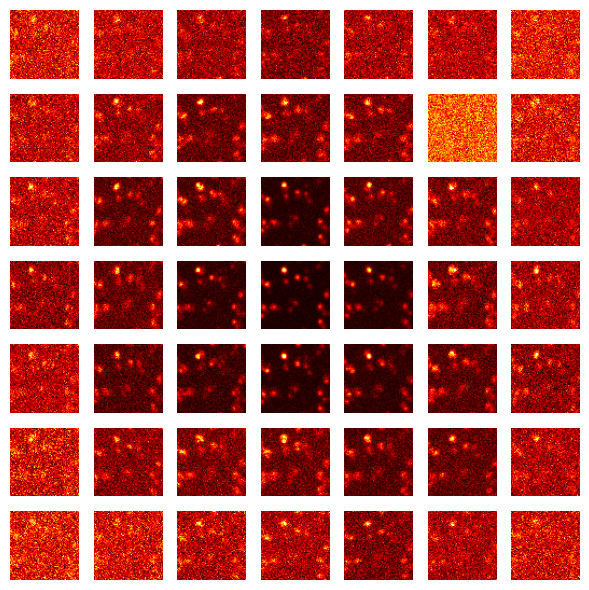

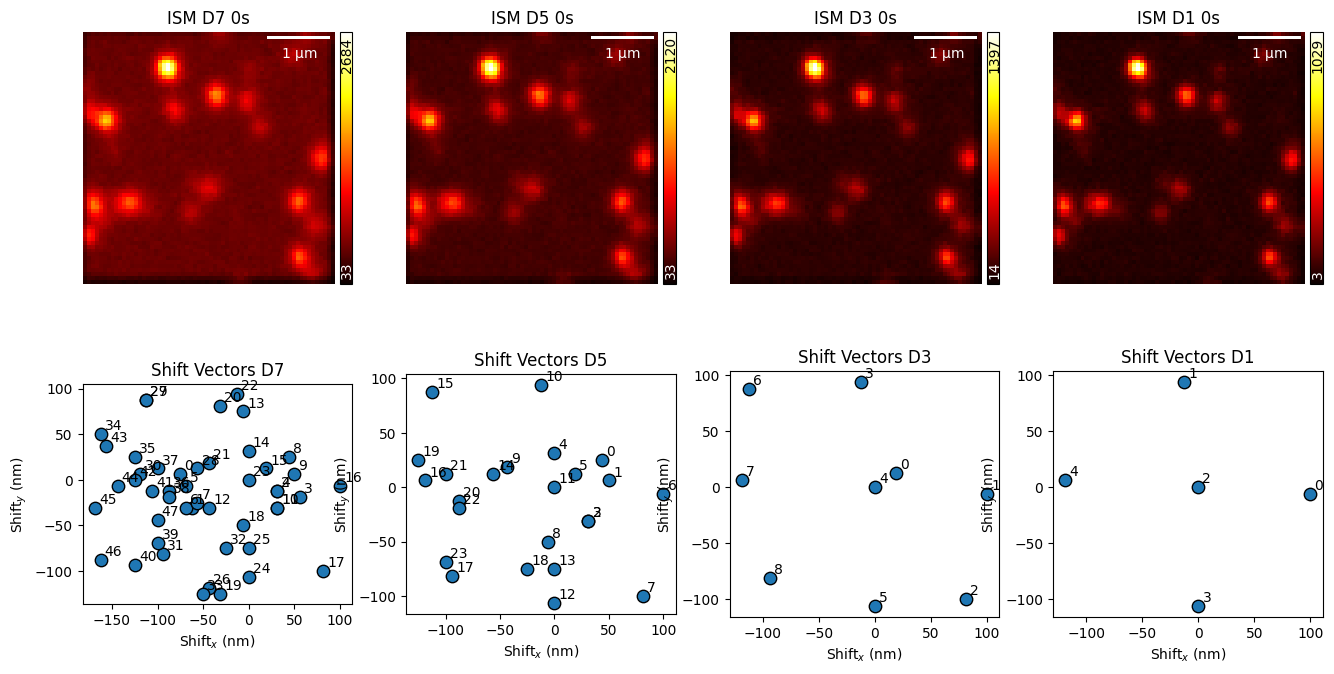

In [172]:
# RUN ISM
#############################################################################################
# CHECK FINGERPRINT
############################################################################################

fingerprint = tool.fingerprint(data.sum(axis=(0,1,4)))
fingerprint[1,5]=(fingerprint[1,4]+fingerprint[1,6])/2 #smooth spad 12
fingerprint_meta[1,5]=(fingerprint_meta[1,4]+fingerprint_meta[1,6])/2
c= int((spadFormat-1)/2)  #change it if the maximum is not at the center


for i in range(7):
    for j in range(7):
        if str(round(fingerprint[i,j]*100/fingerprint[c,c])) != str(round(fingerprint_meta[i,j]*100/fingerprint_meta[c,c])):
            raise 'fingerprint not matching'
        # ax[0].text(j-0.3,i, str(round(fingerprint[i,j]*100/fingerprint[c,c])) + '%', color='limegreen')
        # ax[0].set_title('Experimental fingerprint')
        # ax[1].text(j-0.3,i, str(round(fingerprint_meta[i,j]*100/fingerprint_meta[c,c])) + '%', color='limegreen')
        # ax[1].set_title('Software fingerprint')

fig_1 = gra.ShowDataset(np.sum(data,axis=(z_i,rep_i,t_i)),normalize = False, colorbar=False) # SHOW 49 images


#############################################################################################
# APR
############################################################################################

#ISM image
usf = 10  # upsampling factor = subpixel precision
ref_D5 = 11 # reference image to compute the shift vectors (center spad)
ref_D3 = 4  # reference image to compute the shift vectors (center spad)
ref_D7 = 23 # reference image to compute the shift vectors (center spad)
ref_D1 = 2 # reference image to compute the shift vectors (center spad)


start = time()
shift_vec7, ISM_D7_CH = apr.APR(d7, usf, ref_D7, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
ISM_D7 = ISM_D7_CH.sum(axis=2)
end = time()
TIME_ISM_D7 = end - start

start = time()
shift_vec5, ISM_D5_CH = apr.APR(d5, usf, ref_D5, filter_sigma=1, pxsize = pxsizex*1000) #pxsize in nm
ISM_D5 = ISM_D5_CH.sum(axis=2)
end = time()
TIME_ISM_D5 = end - start

start = time()
shift_vec3, ISM_D3_CH = apr.APR(d3, usf, ref_D3, filter_sigma=1, pxsize = pxsizex*1000)
ISM_D3 = ISM_D3_CH.sum(axis=2)
end = time()
TIME_ISM_D3 = end - start

start = time()
shift_vec1, ISM_D1_CH = apr.APR(d1, usf, ref_D1, filter_sigma=1, pxsize = pxsizex*1000)
ISM_D1 = ISM_D1_CH.sum(axis=2)
end = time()
TIME_ISM_D1 = end - start

fig, ax = plt.subplots(2, 4, figsize=(4*4,8))

gra.ShowImg(ISM_D7, pxsize_x = pxsizex, fig = fig, ax = ax[0,0])
ax[0,0].set_title('ISM D7 ' + str(int(TIME_ISM_D7)) + 's')
gra.PlotShiftVectors(shift_vec7, fig = fig, ax = ax[1,0])
ax[1,0].set_title('Shift Vectors D7')

gra.ShowImg(ISM_D5, pxsize_x = pxsizex, fig = fig, ax = ax[0,1])
ax[0,1].set_title('ISM D5 ' + str(int(TIME_ISM_D5)) + 's')
gra.PlotShiftVectors(shift_vec5, fig = fig, ax = ax[1,1])
ax[1,1].set_title('Shift Vectors D5')

gra.ShowImg(ISM_D3, pxsize_x = pxsizex, fig = fig, ax = ax[0,2])
ax[0,2].set_title('ISM D3 ' + str(int(TIME_ISM_D3)) + 's')
gra.PlotShiftVectors(shift_vec3, fig = fig, ax = ax[1,2])
ax[1,2].set_title('Shift Vectors D3')

gra.ShowImg(ISM_D1, pxsize_x = pxsizex, fig = fig, ax = ax[0,3])
ax[0,3].set_title('ISM D1 ' + str(int(TIME_ISM_D1)) + 's')
gra.PlotShiftVectors(shift_vec1, fig = fig, ax = ax[1,3])
ax[1,3].set_title('Shift Vectors D1')

plt.show()

# #############################################################################################
# # ISM VS SPAD
# ############################################################################################

# fig, ax = plt.subplots(1, 2, figsize=(15,10))

# gra.ShowImg(CENTRAL_SPAD[:,:], pxsize_x = pxsizex, fig = fig, ax = ax[0]) #[422:512,45:135]
# ax[0].set_title('Confocal central spad')

# gra.ShowImg(ISM_D5[:,:], pxsize_x = pxsizex, fig = fig, ax = ax[1]) #[320:356,206:242]
# ax[1].set_title('ISM D5')
# plt.show()

del d1,d3,d5,d7
del ISM_D1_CH, ISM_D3_CH, ISM_D5_CH, ISM_D7_CH
del shift_vec1, shift_vec3, shift_vec5, shift_vec7

# ANALYSIS

In [173]:
# IMAGES IN ISM_D1, ISM_D3, ISM_D5, ISM_D7
img_SPAD = CENTRAL_SPAD # /np.max(CENTRAL_SPAD) #img_sum#np.sum(data,axis=(0,1,4))[:,:,24]#img_deconv[-1,...] #insert here the images 1 and 2 that you want to analyse
img_D1 = ISM_D1 # /np.max(ISM_D1) #img_ism_sum#srrf_ism_1[...]
img_D3 = ISM_D3 #/np.max(ISM_D3) #img_ism_sum#srrf_ism_1[...]
img_D5 = ISM_D5 #/np.max(ISM_D5) #img_ism_sum#srrf_ism_1[...]
img_D7 = ISM_D7 #/np.max(ISM_D7) #img_ism_sum#srrf_ism_1[...]
sum_D1 = D1 #/np.max(D1) #img_ism_sum#srrf_ism_1[...]
sum_D3 = D3 #/np.max(D3) #img_ism_sum#srrf_ism_1[...]
sum_D5 = D5 #/np.max(D5) #img_ism_sum#srrf_ism_1[...]
sum_D7 = D7 #/np.max(D7) #img_ism_sum#srrf_ism_1[...

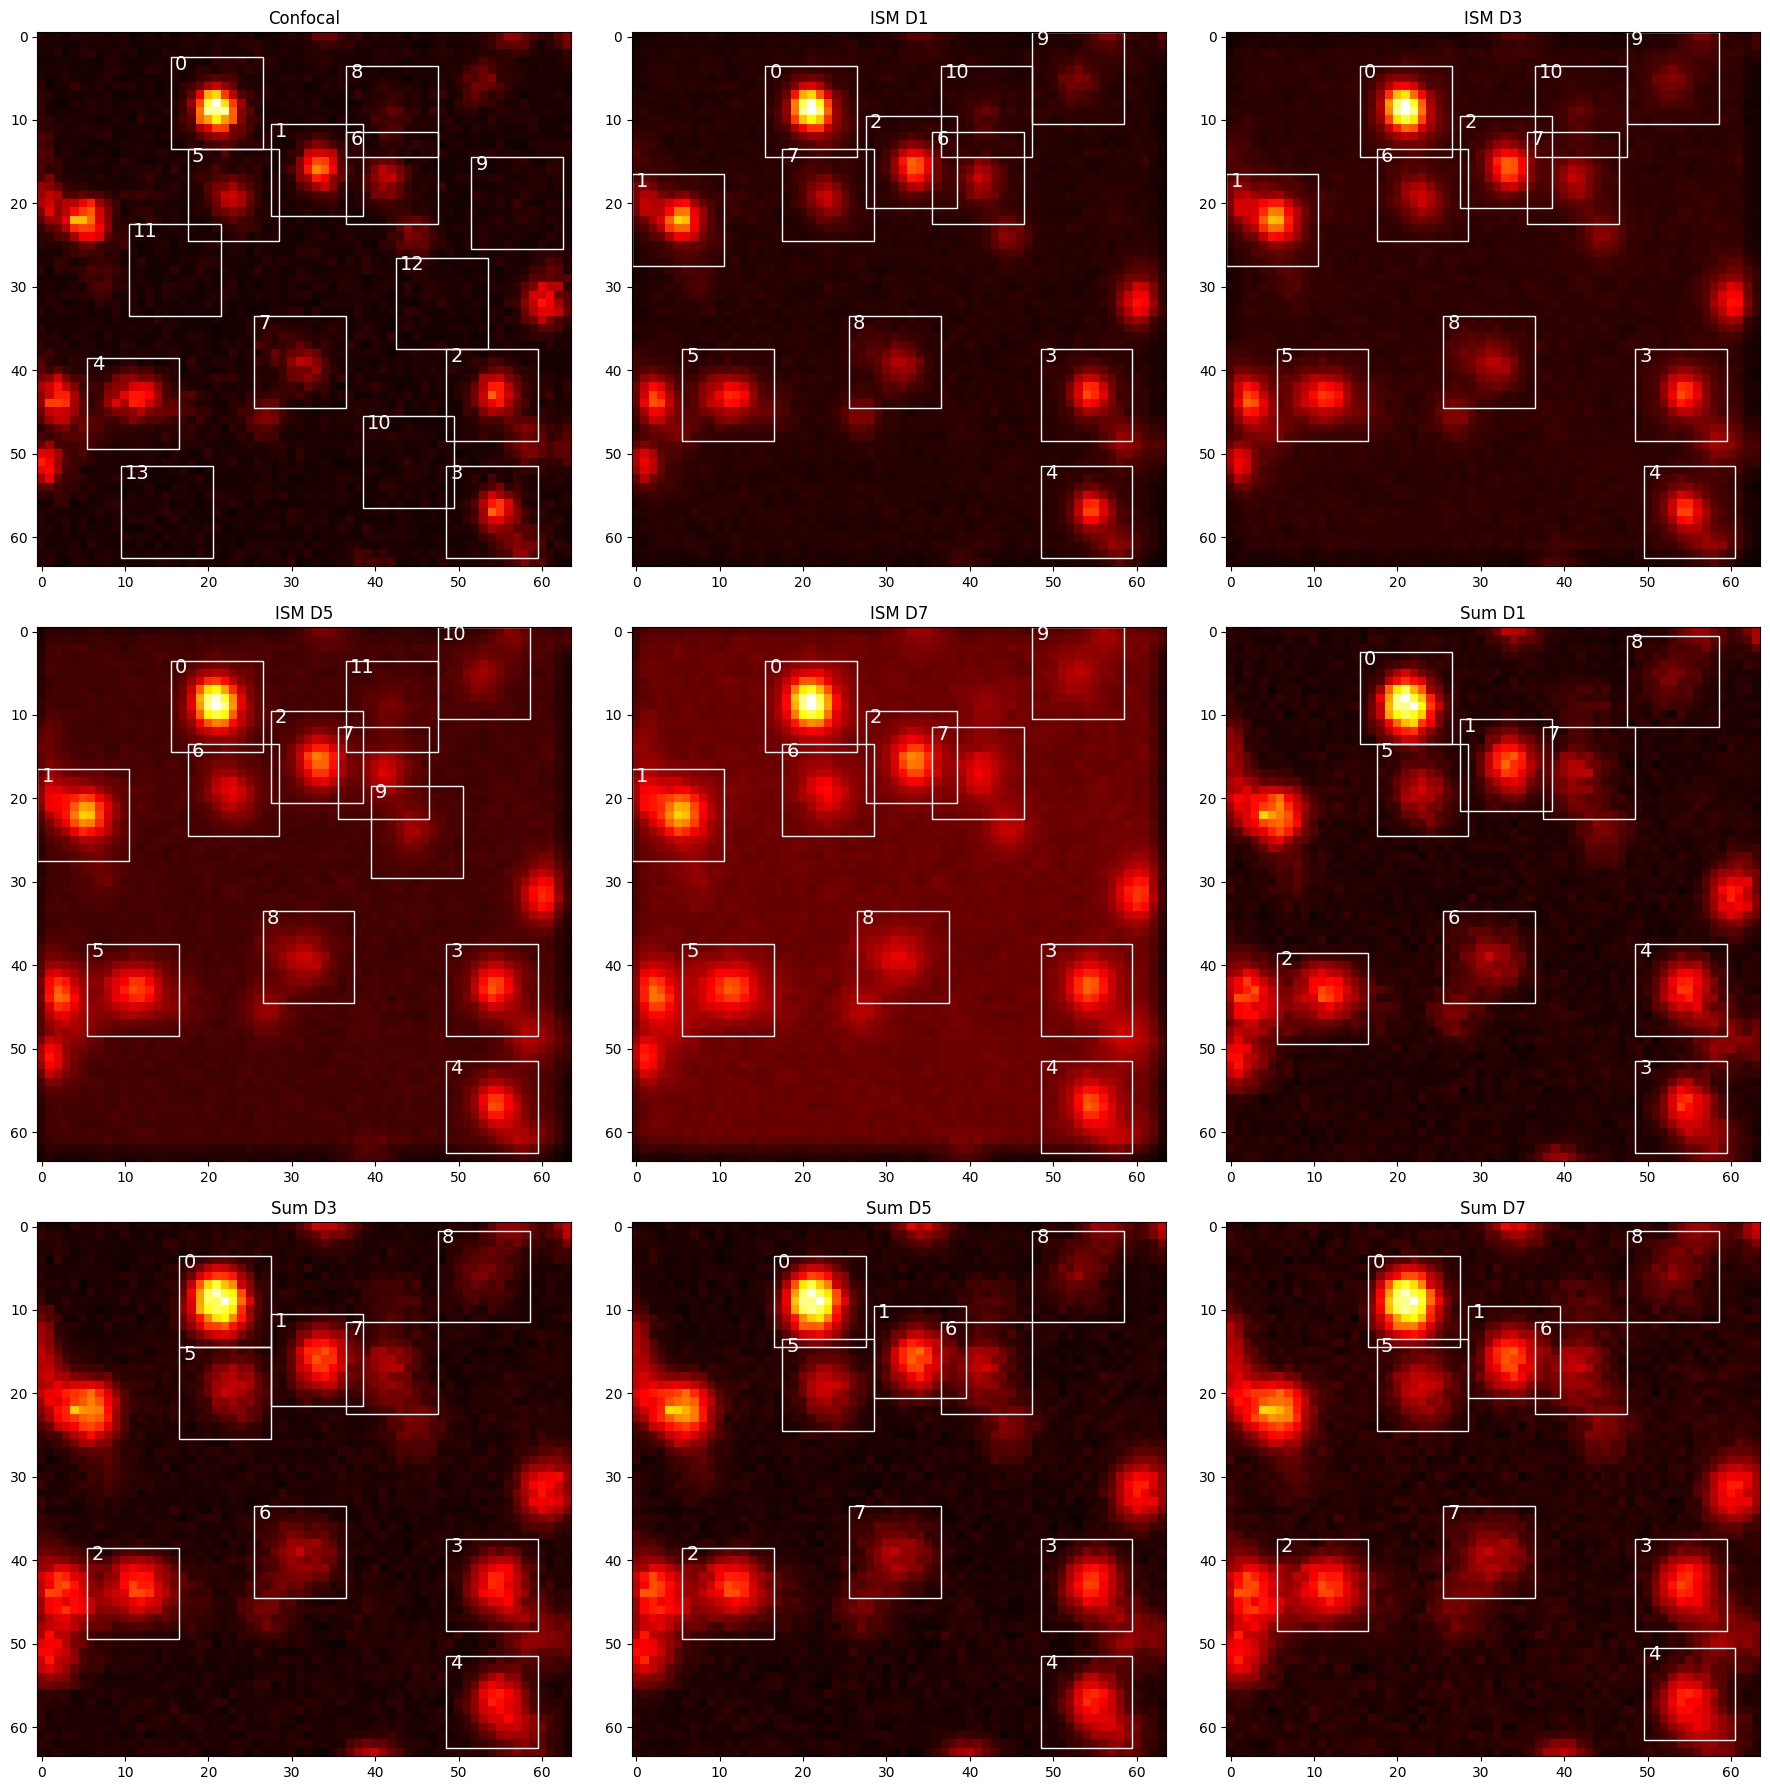

c:\Users\jocar\Desktop\tesi\images\2025 07 07-08 Qdots\Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8


In [174]:
# find peaks

ROIsizeC = 11 # size of the ROI box
radius = ROIsizeC//2
signal_thresh_SPAD = np.mean(img_SPAD)
signal_thresh_D1 = np.mean(img_D1)
signal_thresh_D3 = np.mean(img_D3)
signal_thresh_D5 = np.mean(img_D5)
signal_thresh_D7 = np.mean(img_D7)
signal_thresh_sum_D1 = np.mean(sum_D1)
signal_thresh_sum_D3 = np.mean(sum_D3)
signal_thresh_sum_D5 = np.mean(sum_D5)
signal_thresh_sum_D7 = np.mean(sum_D7)

xc_SPAD=peak_local_max(img_SPAD,min_distance=radius, threshold_abs=signal_thresh_SPAD) # cordinates peaks
# maxvalues = np.array([img_SPAD[xc_SPAD[i,0],xc_SPAD[i,1]] for i in range(xc_SPAD.shape[0])])

xc_D1=peak_local_max(img_D1,min_distance=radius, threshold_abs=signal_thresh_D1) # cordinates peaks
# maxvalues = np.array([img_D1[xc_D1[i,0],xc_D1[i,1]] for i in range(xc_D1.shape[0])])

xc_D3=peak_local_max(img_D3,min_distance=radius, threshold_abs=signal_thresh_D3) # cordinates peaks
# maxvalues = np.array([img_D3[xc_D3[i,0],xc_D3[i,1]] for i in range(xc_D3.shape[0])])

xc_D5=peak_local_max(img_D5,min_distance=radius, threshold_abs=signal_thresh_D5) # cordinates peaks
# maxvalues = np.array([img_D5[xc_D5[i,0],xc_D5[i,1]] for i in range(xc_D5.shape[0])])

xc_D7=peak_local_max(img_D7,min_distance=radius, threshold_abs=signal_thresh_D7) # cordinates peaks
# maxvalues = np.array([img_D7[xc_D7[i,0],xc_D7[i,1]] for i in range(xc_D7.shape[0])])

xc_sum_D1=peak_local_max(sum_D1,min_distance=radius, threshold_abs=signal_thresh_sum_D1) # cordinates peaks
# maxvalues = np.array([sum_D1[xc_sum_D1[i,0],

xc_sum_D3=peak_local_max(sum_D3,min_distance=radius, threshold_abs=signal_thresh_sum_D3) # cordinates peaks
# maxvalues = np.array([sum_D3[xc_sum_D3[i,0],

xc_sum_D5=peak_local_max(sum_D5,min_distance=radius, threshold_abs=signal_thresh_sum_D5) # cordinates peaks
# maxvalues = np.array([sum_D5[xc_sum_D5[i,0],

xc_sum_D7=peak_local_max(sum_D7,min_distance=radius, threshold_abs=signal_thresh_sum_D7) # cordinates peaks
# maxvalues = np.array([sum_D7[xc_sum_D7[i,0],

# if xc_SPAD.shape != xc_D1.shape:
#     raise "xc_D1 != xc_SPAD ha trovato più elementi in uno dei due"

Npart1 = xc_SPAD.shape[0]
Npart2 = xc_D1.shape[0]
Npart3 = xc_D3.shape[0]
Npart4 = xc_D5.shape[0]
Npart5 = xc_D7.shape[0]
Npart6 = xc_sum_D1.shape[0]
Npart7 = xc_sum_D3.shape[0]
Npart8 = xc_sum_D5.shape[0]
Npart9 = xc_sum_D7.shape[0]

fig, axes = plt.subplots(3, 3, figsize=(18, 18))

images = [img_SPAD, img_D1, img_D3, img_D5, img_D7, sum_D1, sum_D3, sum_D5, sum_D7]
coords = [xc_SPAD, xc_D1, xc_D3, xc_D5, xc_D7, xc_sum_D1, xc_sum_D3, xc_sum_D5, xc_sum_D7]
nparts = [Npart1, Npart2, Npart3, Npart4, Npart5, Npart6, Npart7, Npart8, Npart9]
titles = ['Confocal', 'ISM D1', 'ISM D3', 'ISM D5', 'ISM D7', 'Sum D1', 'Sum D3', 'Sum D5', 'Sum D7']

for i in range(9):
    ax = axes[i // 3, i % 3]
    ax.imshow(images[i], cmap='hot')
    ax.set_title(titles[i])
    for l in range(nparts[i]):
        rect = Rectangle((coords[i][l,1]-ROIsizeC/2, coords[i][l,0]-ROIsizeC/2), ROIsizeC, ROIsizeC, linewidth=1, edgecolor='w', facecolor='none')
        ax.add_patch(rect)
        ax.text(coords[i][l,1]-radius, coords[i][l,0]-radius+1, l, fontsize=14, color='white')
plt.tight_layout()
plt.show()

print(filename)


In [178]:

# Initialize ROI_TO_ANALYSE based on the current file
if file == 'Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3':
    ROI_TO_ANALYSE = {
        'ROI_SPAD': (0, 1, 5,),
        'ROI_D1':   (0, 1, 5),
        'ROI_D3':   (0, 1, 4),
        'ROI_D5':   (0, 1, 3),
        'ROI_D7':   (0, 1, 3),
        'ROI_sum_D1': (0, 1, 2),
        'ROI_sum_D3': (0, 1, 2,),
        'ROI_sum_D5': (0, 1, 2,),
        'ROI_sum_D7': (0, 1, 2,)
    }
elif file == 'Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8':
    ROI_TO_ANALYSE = {
        'ROI_SPAD': (0, 1, 2, 3, 4, 5, 6, 7),
        'ROI_D1':   (0, 2, 3, 4, 5, 7, 6, 8),
        'ROI_D3':   (0, 2, 3, 4, 5, 6, 7, 8),
        'ROI_D5':   (0, 2, 3, 4, 5, 6, 7, 8),
        'ROI_D7':   (0, 2, 3, 4, 5, 6, 7, 8),
        'ROI_sum_D1': (0, 1, 4, 3, 2, 5, 7, 6),
        'ROI_sum_D3': (0, 1, 3, 4, 2, 5, 7, 6),
        'ROI_sum_D5': (0, 1, 3, 4, 2, 5, 6, 7),
        'ROI_sum_D7': (0, 1, 3, 4, 2, 5, 6, 7)
    }
elif file == 'Qdots_770nm_34mW_FOV5um_64x64_30rip_5msPixel_ROI5':
    ROI_TO_ANALYSE = {
        'ROI_SPAD': (0, 1, 2, 4, 5, 3, 8),
        'ROI_D1':   (0, 2, 1, 4, 3, 5, 6),
        'ROI_D3':   (0, 2, 1, 4, 3, 5, 6),
        'ROI_D5':   (0, 1, 2, 4, 3, 5, 6),
        'ROI_D7':   (0, 1, 2, 3, 4, 6, 7),
        'ROI_sum_D1': (0, 2, 1, 4, 3, 5, 6),
        'ROI_sum_D3': (0, 2, 1, 4, 3, 5, 6),
        'ROI_sum_D5': (0, 1, 2, 4, 3, 5, 6),
        'ROI_sum_D7': (0, 1, 2, 4, 3, 5, 6)
    }
elif file == 'Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI2':
    ROI_TO_ANALYSE = {
        'ROI_SPAD': (0, 1, 2, 3, 4, 5),
        'ROI_D1':   (0, 1, 2, 4, 3, 5),
        'ROI_D3':   (0, 2, 1, 3, 4, 5),
        'ROI_D5':   (0, 1, 2, 3, 4, 5),
        'ROI_D7':   (0, 1, 2, 3, 4, 5),
        'ROI_sum_D1': (0, 1, 2, 3, 4, 5),
        'ROI_sum_D3': (0, 1, 2, 3, 4, 5),
        'ROI_sum_D5': (0, 1, 2, 3, 4, 5),
        'ROI_sum_D7': (0, 1, 2, 3, 4, 5)
    }
elif file == 'Qdots_770nm_34mW_FOV5um_64x64_50rip_5msPixel_ROI4':
    ROI_TO_ANALYSE = {
        'ROI_SPAD': (0, 2, 5),
        'ROI_D1': (0, 2, 6),
        'ROI_D3': (0, 2, 5),
        'ROI_D5': (0, 2, 5),
        'ROI_D7': (0, 2, 6),
        'ROI_sum_D1': (0, 2, 5),
        'ROI_sum_D3': (0, 2, 6),
        'ROI_sum_D5': (0, 2, 4),
        'ROI_sum_D7': (0, 2, 4)
    }
elif file == 'Qdots_770nm_34mW_FOV3um_32x32_50rip_5msPixel_ROI7':
    ROI_TO_ANALYSE = {
        'ROI_SPAD': (0, 1),
        'ROI_D1': (0, 1),
        'ROI_D3': (0, 1),
        'ROI_D5': (0, 1),
        'ROI_D7': (0, 1)
    }
elif file == 'Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6':
    ROI_TO_ANALYSE = {
        'ROI_SPAD': (2, 8, 9, 10, 3),
        'ROI_D1': (1, 8, 6, 5, 3),
        'ROI_D3': (1, 8, 6, 5, 3),
        'ROI_D5': (1, 8, 5, 6, 3),
        'ROI_D7': (1, 8, 6, 5, 3)
    }
elif file == 'Qdots_37mW_FOV5um_64x64_100rip_5msPixel_ROI3':
    ROI_TO_ANALYSE = {
        'ROI_SPAD': (2, 0, 1, 5),
        'ROI_D1':   (0, 1, 2, 5),
        'ROI_D3':   (0, 1, 2, 4),
        'ROI_D5':   (0, 1, 2, 3),
        'ROI_D7':   (0, 1, 2, 3)
    }
else:
    ROI_TO_ANALYSE = {}
# ROI_TO_ANALYSE = { # Qdots_770nm_34mW_FOV3um_32x32_50rip_5msPixel_ROI7
#     'ROI_SPAD': (0,3,4),
#     'ROI_D1': (0,2,3),
#     'ROI_D3': (0,1,2),
#     'ROI_D5': (0,1,2),
#     'ROI_D7': (0,1,2)
# }

# ROI_TO_ANALYSE = { # Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_ROI8
#     'ROI_SPAD': (0,1,2,3,4,5,6,7),
#     'ROI_D1':   (0,2,3,4,5,7,6,8),
#     'ROI_D3':   (0,2,3,4,5,6,7,8),
#     'ROI_D5':   (0,2,3,4,5,6,7,8),
#     'ROI_D7':   (0,2,3,4,5,6,7,8)
# }

# ROI_TO_ANALYSE = { # Qdots_770nm_34mW_FOV5um_64x64_30rip_5msPixel_ROI5
#     'ROI_SPAD': (0,1,2,4,5,3,8),
#     'ROI_D1':   (0,2,1,4,3,5,6),
#     'ROI_D3':   (0,2,1,4,3,5,6),
#     'ROI_D5':   (0,1,2,4,3,5,6),
#     'ROI_D7':   (0,1,2,3,4,6,7)
# }

# ROI_TO_ANALYSE = { # Qdots_770nm_34mW_FOV5um_64x64_50rip_5msPixel_ROI4
#     'ROI_SPAD': (0,2,5),
#     'ROI_D1': (0,2,6),
#     'ROI_D3': (0,2,5),
#     'ROI_D5': (0,2,5),
#     'ROI_D7': (0,2,6)
# }


# ROI_TO_ANALYSE = { # Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6
#     'ROI_SPAD': (2,8,9,10,3,),
#     'ROI_D1': (1,8,6,5,3,),
#     'ROI_D3': (1,8,6,5,3,),
#     'ROI_D5': (1,8,5,6,3,),
#     'ROI_D7': (1,8,6,5,3,)
# }

In [176]:
# # Remove specific particles
# #Refresh the image above to see the updated indexes after every deletion!

# wh = img_1.shape[0] # image height and width
# halfsize = ROIsizeC / 2

# xc1 = xc2

# # remove elements from borders
# mask = (
#     ((xc1 + (halfsize, halfsize)) < wh).all(axis=1) &
#     ((xc1 - (halfsize, halfsize)) >= 0).all(axis=1)
# )

# xc1 = xc1[mask] # coordinate centrali dei box
# Npart = xc1.shape[0] # numero di box

# #[y,x]

In [179]:
def erfC(x, amp, xc, w, offset): 
    return amp*np.pi*w*w*(1-scipy.special.erf((xc-x)/(np.sqrt(2.0)*w)))+offset*ROIsizeC*x # added minus sign

Δ = ROIsizeC // 2

ISM_DATAFRAME = pd.DataFrame() # pd.read_csv('./images/ISM/ISM_FWHM.csv')

result = []

counter = -1
for i in range(len(ROI_TO_ANALYSE['ROI_SPAD'])):
    # Extract ROIs
    counter += 1
    # if counter > 1:
    #     break

    y,x = xc_SPAD[ROI_TO_ANALYSE['ROI_SPAD'][i]]
    index_ROI_CENTRAL_SPAD = ROI_TO_ANALYSE['ROI_SPAD'][i]
    ROI_SPAD = img_SPAD[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_D1[ROI_TO_ANALYSE['ROI_D1'][i]]
    index_ROI_CENTRAL_D1 = ROI_TO_ANALYSE['ROI_D1'][i]
    ROI_D1 = img_D1[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_D3[ROI_TO_ANALYSE['ROI_D3'][i]]
    index_ROI_CENTRAL_D3 = ROI_TO_ANALYSE['ROI_D3'][i]
    ROI_D3 = img_D3[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_D5[ROI_TO_ANALYSE['ROI_D5'][i]]
    index_ROI_CENTRAL_D5 = ROI_TO_ANALYSE['ROI_D5'][i]
    ROI_D5 = img_D5[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_D7[ROI_TO_ANALYSE['ROI_D7'][i]]
    index_ROI_CENTRAL_D7 = ROI_TO_ANALYSE['ROI_D7'][i]
    ROI_D7 = img_D7[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_sum_D1[ROI_TO_ANALYSE['ROI_sum_D1'][i]]
    index_ROI_CENTRAL_sum_D1 = ROI_TO_ANALYSE['ROI_sum_D1'][i]
    ROI_sum_D1 = sum_D1[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_sum_D3[ROI_TO_ANALYSE['ROI_sum_D3'][i]]
    index_ROI_CENTRAL_sum_D3 = ROI_TO_ANALYSE['ROI_sum_D3'][i]
    ROI_sum_D3 = sum_D3[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    y,x = xc_sum_D5[ROI_TO_ANALYSE['ROI_sum_D5'][i]]
    index_ROI_CENTRAL_sum_D5 = ROI_TO_ANALYSE['ROI_sum_D5'][i]
    ROI_sum_D5 = sum_D5[y-Δ:y+Δ+1, x-Δ:x+Δ+1]
    
    y,x = xc_sum_D7[ROI_TO_ANALYSE['ROI_sum_D7'][i]]
    index_ROI_CENTRAL_sum_D7 = ROI_TO_ANALYSE['ROI_sum_D7'][i]
    ROI_sum_D7 = sum_D7[y-Δ:y+Δ+1, x-Δ:x+Δ+1]

    # fit with CDF:
    # Define colors for each ROI
    colors = {
        'ROI_SPAD': 'tab:blue',
        'ROI_D1': 'tab:orange',
        'ROI_D3': 'tab:green',
        'ROI_D5': 'tab:red',
        'ROI_D7': 'tab:purple',
        'ROI_sum_D1': 'tab:brown',
        'ROI_sum_D3': 'tab:pink',
        'ROI_sum_D5': 'tab:gray',
        'ROI_sum_D7': 'tab:olive'
    }

    limits = ([0, 0, 0, -np.inf], [np.inf, ROIsizeC, np.inf, np.inf])

    X = np.cumsum(ROI_SPAD.sum(axis=1))
    # plt.plot(X, label='ROI_SPAD', color=colors['ROI_SPAD'])
    popt_SPAD, pcov_SPAD = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[-1], ROIsizeC/2, 2., 0.],bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_SPAD), '--', label='Fit SPAD', color=colors['ROI_SPAD'])
    FWHM_SPAD = np.round(2.355 * popt_SPAD[2],4)
    sigma_FWHM_SPAD = np.round(2.355 * np.sqrt(np.diag(pcov_SPAD))[2],4)
    # print('FWHM SPAD: (' + str(np.round(FWHM_SPAD,2)) + '±' + str(np.round(sigma_FWHM_SPAD,2)) + ') px')

    X = np.cumsum(ROI_D1.sum(axis=1))
    # plt.plot(X, label='ROI_D1', color=colors['ROI_D1'])
    popt_D1, pcov_D1 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=popt_SPAD, bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_D1), '--', label='Fit D1', color=colors['ROI_D1'])
    FWHM_D1 = np.round(2.355 * popt_D1[2],4)
    sigma_FWHM_D1 = np.round(2.355 * np.sqrt(np.diag(pcov_D1))[2],4)
    # print('FWHM D1: (' + str(np.round(FWHM_D1,2)) + '±' + str(np.round(sigma_FWHM_D1,2)) + ') px')

    X = np.cumsum(ROI_D3.sum(axis=1))
    # plt.plot(X, label='ROI_D3', color=colors['ROI_D3'])
    popt_D3, pcov_D3 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[ROIsizeC//2], ROIsizeC/2, 2., 0.], bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_D3), '--', label='Fit D3', color=colors['ROI_D3'])
    FWHM_D3 = np.round(2.355 * popt_D3[2],4)
    sigma_FWHM_D3 = np.round(2.355 * np.sqrt(np.diag(pcov_D3))[2],4)
    # print('FWHM D3: (' + str(np.round(FWHM_D3,2)) + '±' + str(np.round(sigma_FWHM_D3,2)) + ') px')

    X = np.cumsum(ROI_D5.sum(axis=1))
    # plt.plot(X, label='ROI_D5', color=colors['ROI_D5'])
    popt_D5, pcov_D5 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[ROIsizeC//2], ROIsizeC/2, 2., 0.], bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_D5), '--', label='Fit D5', color=colors['ROI_D5'])
    FWHM_D5 = np.round(2.355 * popt_D5[2],4)
    sigma_FWHM_D5 = np.round(2.355 * np.sqrt(np.diag(pcov_D5))[2],4)
    # print('FWHM D5: (' + str(np.round(FWHM_D5,2)) + '±' + str(np.round(sigma_FWHM_D5,2)) + ') px')

    X = np.cumsum(ROI_D7.sum(axis=1))
    # plt.plot(X, label='ROI_D7', color=colors['ROI_D7'])
    popt_D7, pcov_D7 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[ROIsizeC//2], ROIsizeC/2, 2., 0.], bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_D7), '--', label='Fit D7', color=colors['ROI_D7'])
    FWHM_D7 = np.round(2.355 * popt_D7[2],4)
    sigma_FWHM_D7 = np.round(2.355 * np.sqrt(np.diag(pcov_D7))[2],4)
    # print('FWHM D7: (' + str(np.round(FWHM_D7,2)) + '±' + str(np.round(sigma_FWHM_D7,2)) + ') px')

    X = np.cumsum(ROI_sum_D1.sum(axis=1))
    # plt.plot(X, label='ROI_sum_D1', color=colors['ROI_sum_D1'])
    popt_sum_D1, pcov_sum_D1 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[ROIsizeC//2], ROIsizeC/2, 2., 0.], bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_sum_D1), '--', label='Fit sum_D1', color=colors['ROI_sum_D1'])
    FWHM_sum_D1 = np.round(2.355 * popt_sum_D1[2],4)
    sigma_FWHM_sum_D1 = np.round(2.355 * np.sqrt(np.diag(pcov_sum_D1))[2],4)
    # print('FWHM sum_D1: (' + str(np.round(FWHM_sum_D1,2)) + '±' + str(np.round(sigma_FWHM_sum_D1,2)) + ') px')

    X = np.cumsum(ROI_sum_D3.sum(axis=1))
    # plt.plot(X, label='ROI_sum_D3', color=colors['ROI_sum_D3'])
    popt_sum_D3, pcov_sum_D3 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[ROIsizeC//2], ROIsizeC/2, 2., 0.], bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_sum_D3), '--', label='Fit sum_D3', color=colors['ROI_sum_D3'])
    FWHM_sum_D3 = np.round( 2.355 * popt_sum_D3[2],4)
    sigma_FWHM_sum_D3 = np.round(2.355 * np.sqrt(np.diag(pcov_sum_D3))[2],4)
    # print('FWHM sum_D3: (' + str(np.round(FWHM_sum_D3,2)) + '±' + str(np.round(sigma_FWHM_sum_D3,2)) + ') px')

    X = np.cumsum(ROI_sum_D5.sum(axis=1))
    # plt.plot(X, label='ROI_sum_D5', color=colors['ROI_sum_D5'])
    popt_sum_D5, pcov_sum_D5 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[ROIsizeC//2], ROIsizeC/2, 2., 0.], bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_sum_D5), '--', label='Fit sum_D5', color=colors['ROI_sum_D5'])
    FWHM_sum_D5 = np.round(2.355 * popt_sum_D5[2],4)
    sigma_FWHM_sum_D5 = np.round(2.355 * np.sqrt(np.diag(pcov_sum_D5))[2],4)
    # print('FWHM sum_D5: (' + str(np.round(FWHM_sum_D5,2)) + '±' + str(np.round(sigma_FWHM_sum_D5,2)) + ') px')

    X = np.cumsum(ROI_sum_D7.sum(axis=1))
    # plt.plot(X, label='ROI_sum_D7', color=colors['ROI_sum_D7'])
    popt_sum_D7, pcov_sum_D7 = curve_fit(erfC, np.arange(ROIsizeC), X, p0=[X[ROIsizeC//2], ROIsizeC/2, 2., 0.], bounds=limits, maxfev=10000)
    # plt.plot(erfC(np.arange(ROIsizeC), *popt_sum_D7), '--', label='Fit sum_D7', color=colors['ROI_sum_D7'])
    FWHM_sum_D7 = np.round( 2.355 * popt_sum_D7[2],4)
    sigma_FWHM_sum_D7 = np.round(2.355 * np.sqrt(np.diag(pcov_sum_D7))[2],4)
    # print('FWHM sum_D7: (' + str(np.round(FWHM_sum_D7,2)) + '±' + str(np.round(sigma_FWHM_sum_D7,2)) + ') px')

    FWHM_values = {
        'FILE': file,
        
        'CENTRAL SPAD': FWHM_SPAD,
        'ISM_D1': FWHM_D1,
        'ISM_D3': FWHM_D3,
        'ISM_D5': FWHM_D5,
        'ISM_D7': FWHM_D7,
        'sum_ISM_D1': FWHM_sum_D1,
        'sum_ISM_D3': FWHM_sum_D3,
        'sum_ISM_D5': FWHM_sum_D5,
        'sum_ISM_D7': FWHM_sum_D7,

        'err CENTAL SPAD': sigma_FWHM_SPAD,
        'err ISM_D1': sigma_FWHM_D1,
        'err ISM_D3': sigma_FWHM_D3,
        'err ISM_D5': sigma_FWHM_D5,
        'err ISM_D7': sigma_FWHM_D7,
        'err sum_ISM_D1': sigma_FWHM_sum_D1,
        'err sum_ISM_D3': sigma_FWHM_sum_D3,
        'err sum_ISM_D5': sigma_FWHM_sum_D5,
        'err sum_ISM_D7': sigma_FWHM_sum_D7,
    
        'ROI CENTRAL SPAD': index_ROI_CENTRAL_SPAD,
        'ROI ISM_D1': index_ROI_CENTRAL_D1,
        'ROI ISM_D3': index_ROI_CENTRAL_D3,
        'ROI ISM_D5': index_ROI_CENTRAL_D5,
        'ROI ISM_D7': index_ROI_CENTRAL_D7,
        'ROI sum_ISM_D1': index_ROI_CENTRAL_sum_D1,
        'ROI sum_ISM_D3': index_ROI_CENTRAL_sum_D3,
        'ROI sum_ISM_D5': index_ROI_CENTRAL_sum_D5,
        'ROI sum_ISM_D7': index_ROI_CENTRAL_sum_D7
    }

    result.append(FWHM_values)
    # CENTRAL SPAD, ISM_D1, ISM_D3, ISM_D5, ISM_D7, sum ISM_D1, sum ISM_D3, sum ISM_D5, sum ISM_D7, err CENTAL SPAD, err ISM_D1, err ISM_D3, err ISM_D5, err ISM_D7, err sum ISM_D1, err sum ISM_D3, err sum ISM_D5, err sum_ISM_D7, FILE, ROI CENTRAL SPAD, ROI ISM_D1, ROI ISM_D3, ROI ISM_D5, ROI ISM_D7, ROI sum ISM_D1, ROI sum ISM_D3, ROI sum ISM_D5, ROI sum ISM_D7
    # ISM_DATAFRAME.loc[len(ISM_DATAFRAME)] = {
    #     'CENTRAL SPAD': float(FWHM_SPAD),
    #     'ISM_D1': float(FWHM_D1),
    #     'ISM_D3': float(FWHM_D3),
    #     'ISM_D5': float(FWHM_D5),
    #     'ISM_D7': float(FWHM_D7),
    #     'sum ISM_D1': float(FWHM_sum_D1),
    #     'sum ISM_D3': float(FWHM_sum_D3),
    #     'sum ISM_D5': float(FWHM_sum_D5),
    #     'sum ISM_D7': float(FWHM_sum_D7),
    #     'err CENTAL SPAD': float(sigma_FWHM_SPAD),
    #     'err ISM_D1': float(sigma_FWHM_D1),
    #     'err ISM_D3': float(sigma_FWHM_D3),
    #     'err ISM_D5': float(sigma_FWHM_D5),
    #     'err ISM_D7': float(sigma_FWHM_D7),
    #     'err sum_ISM_D1': float(sigma_FWHM_sum_D1),
    #     'err sum_ISM_D3': float(sigma_FWHM_sum_D3),
    #     'err sum_ISM_D5': float(sigma_FWHM_sum_D5),
    #     'err sum_ISM_D7': float(sigma_FWHM_sum_D7),
    #     'FILE': str(file),
    #     'ROI CENTRAL SPAD': int(index_ROI_CENTRAL_SPAD),
    #     'ROI ISM_D1': int(index_ROI_CENTRAL_D1),
    #     'ROI ISM_D3': int(index_ROI_CENTRAL_D3),
    #     'ROI ISM_D5': int(index_ROI_CENTRAL_D5),
    #     'ROI ISM_D7': int(index_ROI_CENTRAL_D7),
    #     'ROI sum_ISM_D1': int(index_ROI_CENTRAL_sum_D1),
    #     'ROI sum_ISM_D3': int(index_ROI_CENTRAL_sum_D3),
    #     'ROI sum_ISM_D5': int(index_ROI_CENTRAL_sum_D5),
    #     'ROI sum_ISM_D7': int(index_ROI_CENTRAL_sum_D7),
    # }

display(pd.DataFrame(result))

# ISM_DATAFRAME.to_csv('./images/ISM/ISM_FWHM.csv', index=False)


,FILE,CENTRAL SPAD,ISM_D1,ISM_D3,ISM_D5,ISM_D7,sum_ISM_D1,sum_ISM_D3,sum_ISM_D5,sum_ISM_D7,...,err sum_ISM_D7,ROI CENTRAL SPAD,ROI ISM_D1,ROI ISM_D3,ROI ISM_D5,ROI ISM_D7,ROI sum_ISM_D1,ROI sum_ISM_D3,ROI sum_ISM_D5,ROI sum_ISM_D7
0,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,3.5657,4.7277,5.3594,5.9124,6.4039,6.3819,6.1344,6.5579,7.1661,...,0.0660,0,0,0,0,0,0,0,0,0
1,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,4.7262,6.7591,3.0401,2.8927,8.0424,6.2703,6.7553,2.9518,1.9911,...,4.0297,1,2,2,2,2,1,1,1,1
2,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,3.1869,6.0555,6.6993,7.1997,7.9655,6.6657,7.2374,7.6946,8.6031,...,0.1038,2,3,3,3,3,4,3,3,3
3,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,2.8661,6.6842,7.2380,7.6511,8.1165,7.4279,7.9712,8.6315,0.0019,...,0.0000,3,4,4,4,4,3,4,4,4
4,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,4.4309,6.3032,6.5933,6.9971,7.6285,5.9145,6.4239,6.8098,8.2123,...,0.0594,4,5,5,5,5,2,2,2,2
5,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,6.6285,7.4826,7.7666,8.1086,8.8316,7.8648,7.2117,8.9031,9.7482,...,0.1061,5,7,6,6,6,5,5,5,5
6,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,2.7082,7.3144,7.7447,8.1029,9.0205,8.5657,9.0137,9.2716,10.5093,...,0.2917,6,6,7,7,7,7,7,6,6
7,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,2.6477,7.3249,7.7163,8.3716,9.1483,8.0561,8.7513,9.5733,0.5503,...,1401.6626,7,8,8,8,8,6,6,7,7


In [ ]:
# ISM_DATAFRAME.to_csv('./images/ISM/ISM_FWHM.csv', index=False)

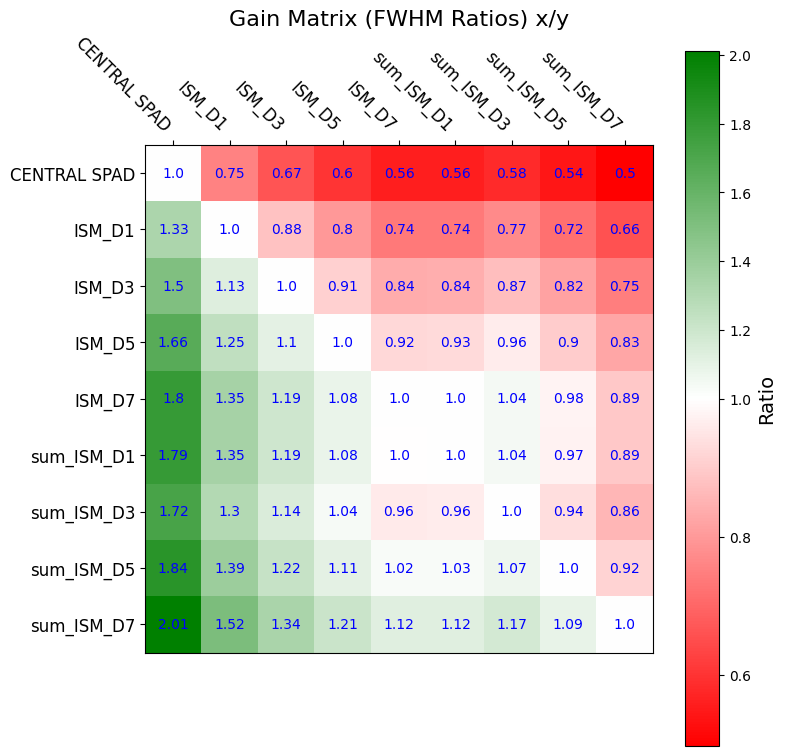

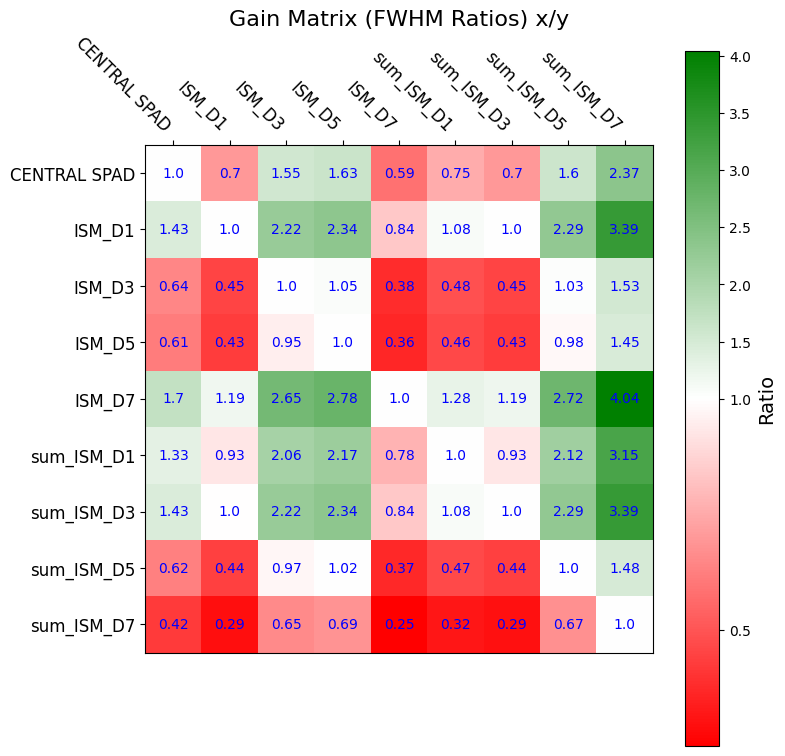

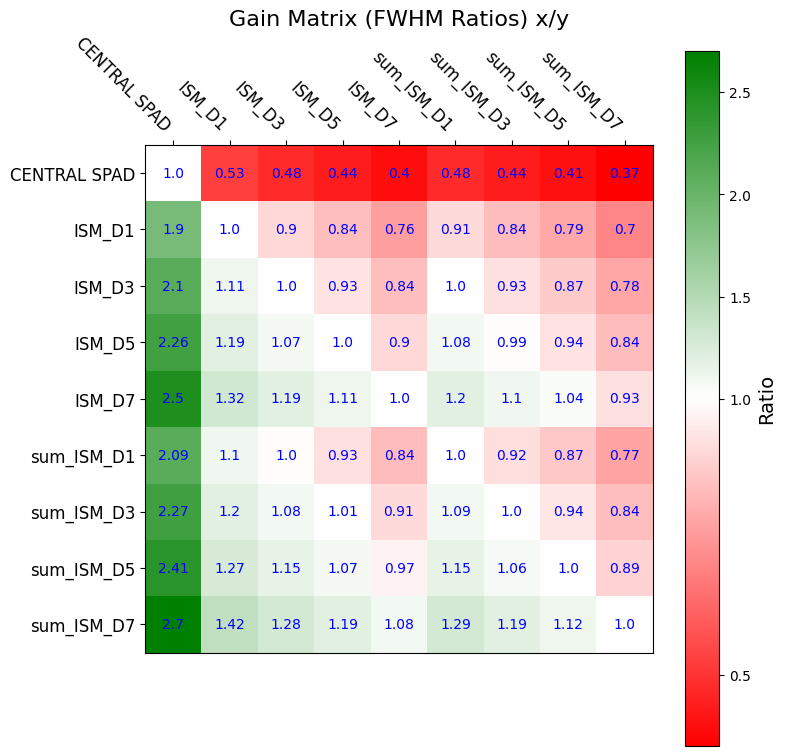

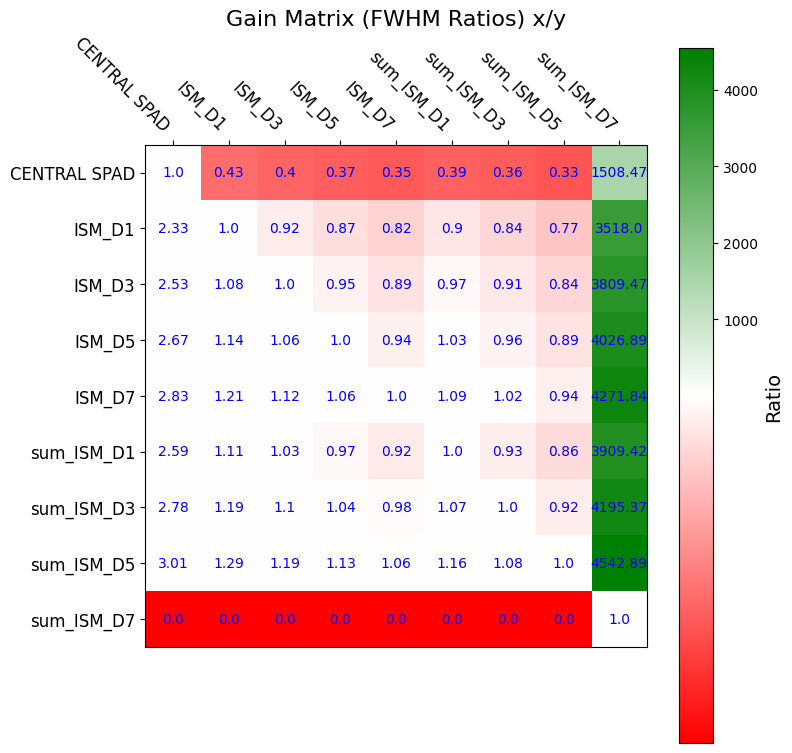

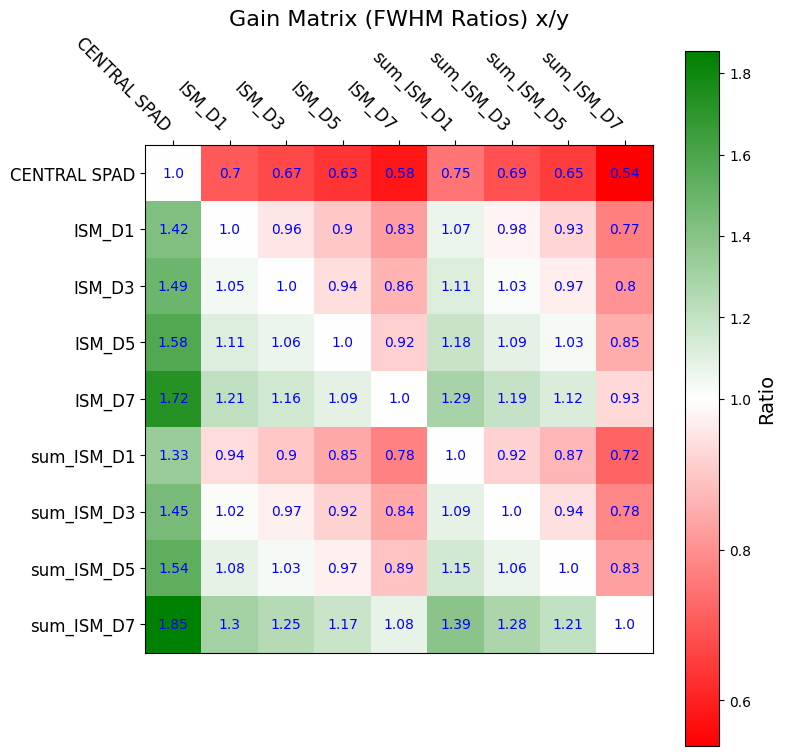

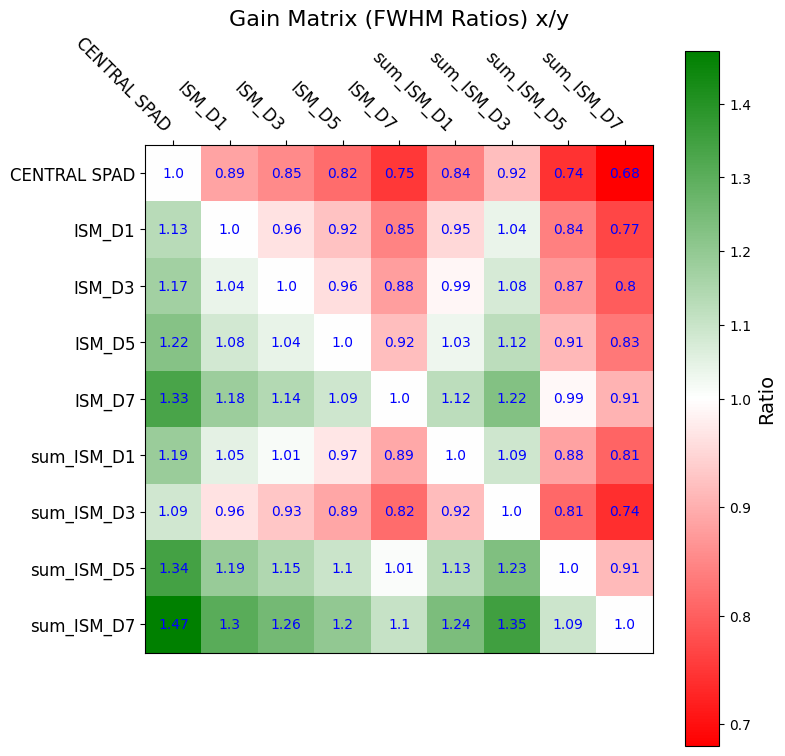

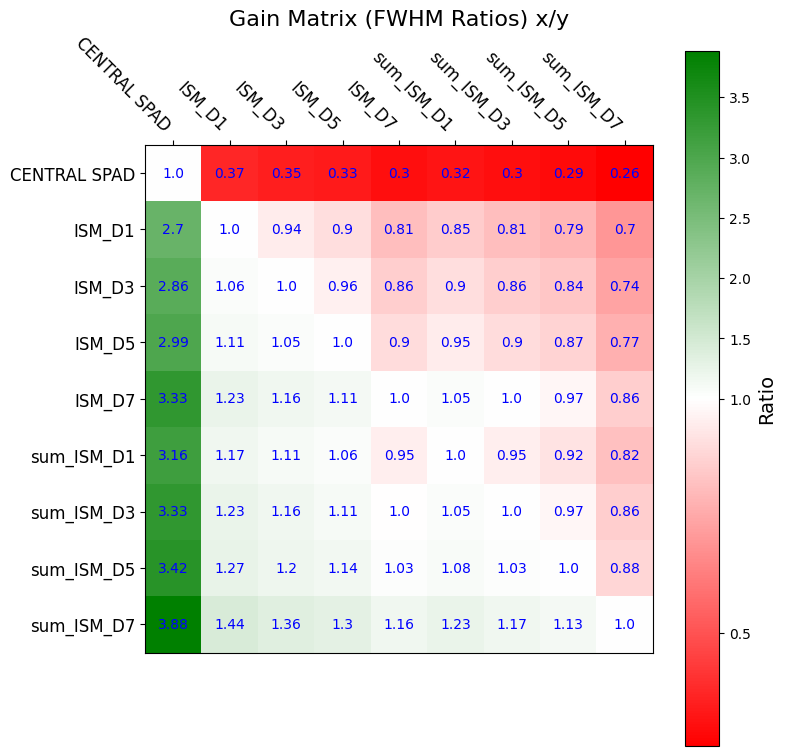

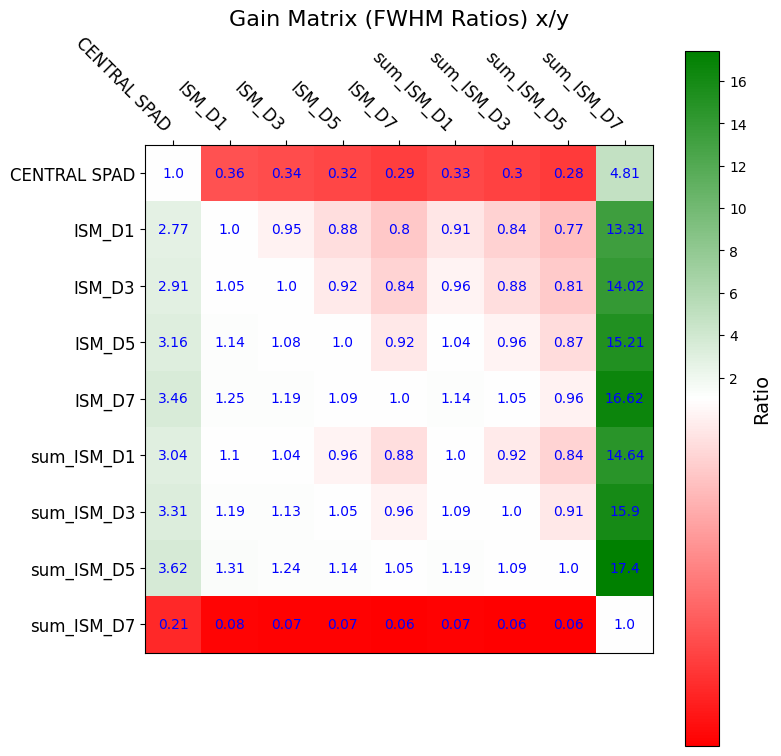

In [180]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

for index in range(len(result)):
    filter = ['CENTRAL SPAD', 'ISM_D1', 'ISM_D3', 'ISM_D5', 'ISM_D7', 'sum_ISM_D1', 'sum_ISM_D3', 'sum_ISM_D5', 'sum_ISM_D7']
    compar = {k: result[index][k] for k in filter if k in result[0]}  # Take the first dictionary from the list

    labels = list(compar.keys())
    matrix_guadagno = np.zeros((len(labels), len(labels)))

    for k, v in enumerate(compar.values()):
        for l, w in enumerate(compar.values()):
            matrix_guadagno[k, l] = np.round(v / w, 4)

    cmap = LinearSegmentedColormap.from_list('red_white_green', ['red', 'white', 'green'])
    norm = TwoSlopeNorm(vmin=matrix_guadagno.min(), vcenter=1.0, vmax=matrix_guadagno.max())

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(matrix_guadagno,  cmap=cmap, norm=norm)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Ratio', fontsize=14)

    # Set axis labels and ticks
    ax.set_xticks(np.arange(len(labels)))
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=-45, ha='right', fontsize=12)
    ax.set_yticklabels(labels, fontsize=12)
    #ax.set_xlabel('Compared', fontsize=14)
    #ax.set_ylabel('Reference', fontsize=14)
    ax.set_title('Gain Matrix (FWHM Ratios) x/y', fontsize=16)

    # Annotate values
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{np.round(matrix_guadagno[i, j], 2)}", ha="center", va="center", color="blue", fontsize=10)

    plt.tight_layout()
    plt.show()

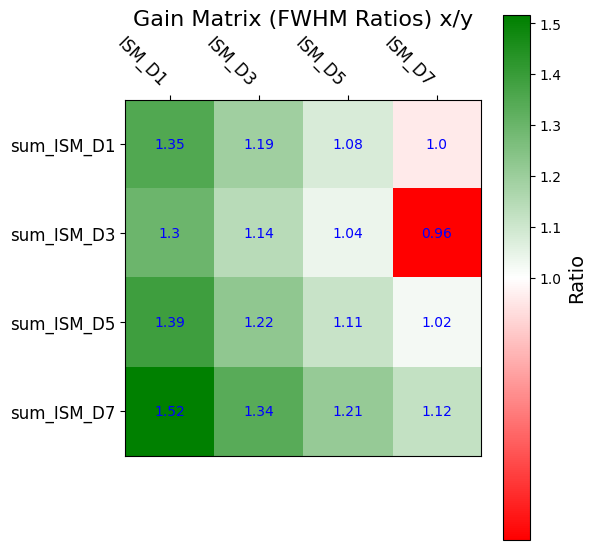

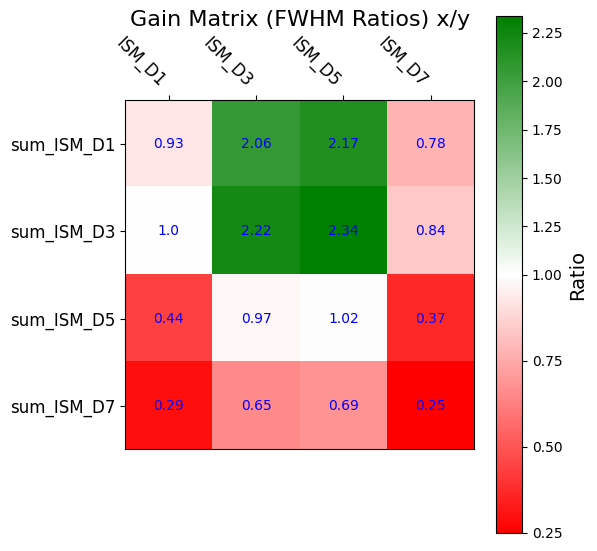

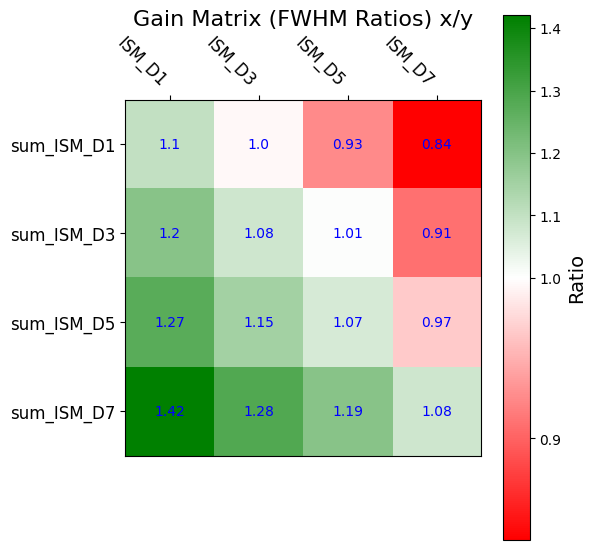

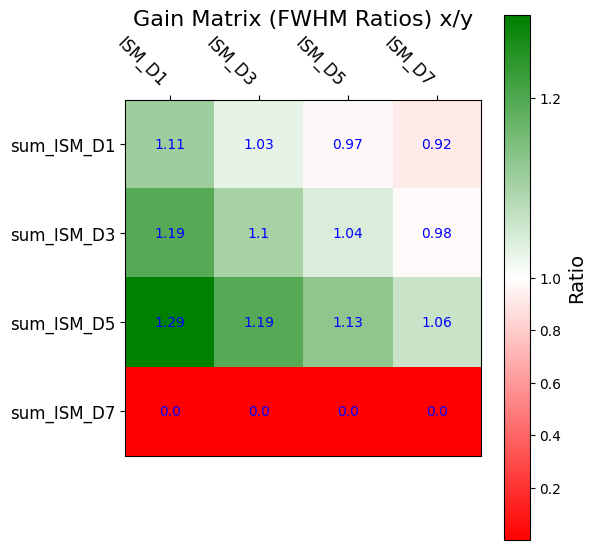

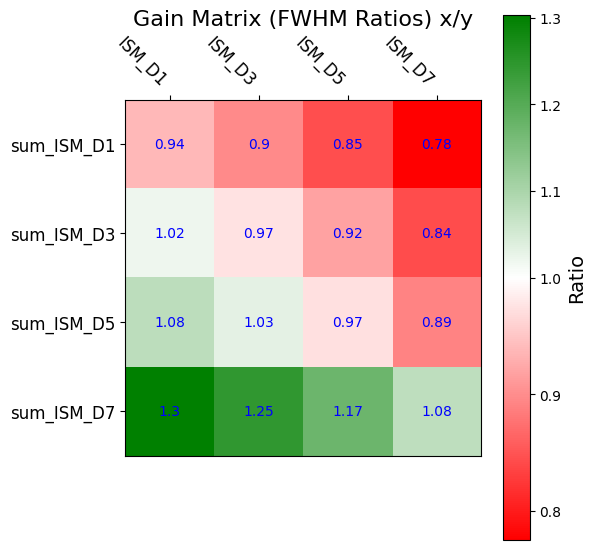

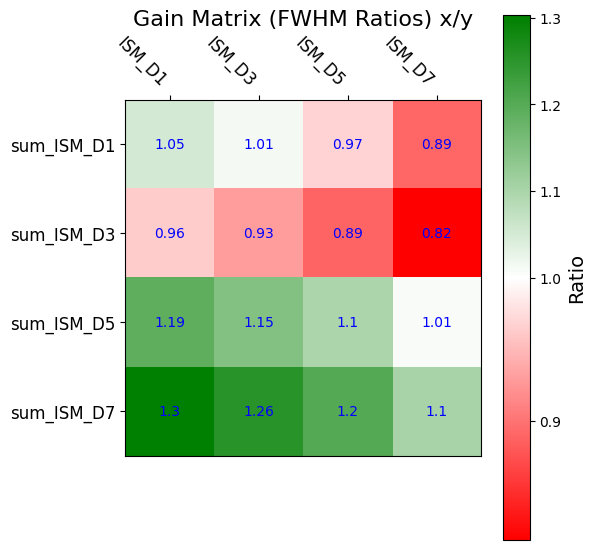

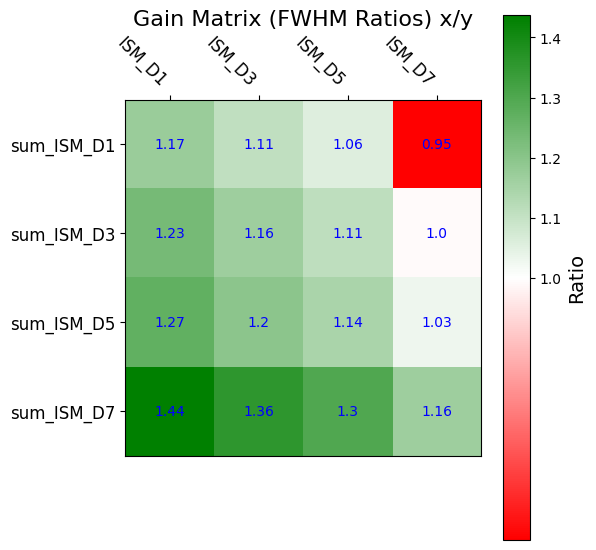

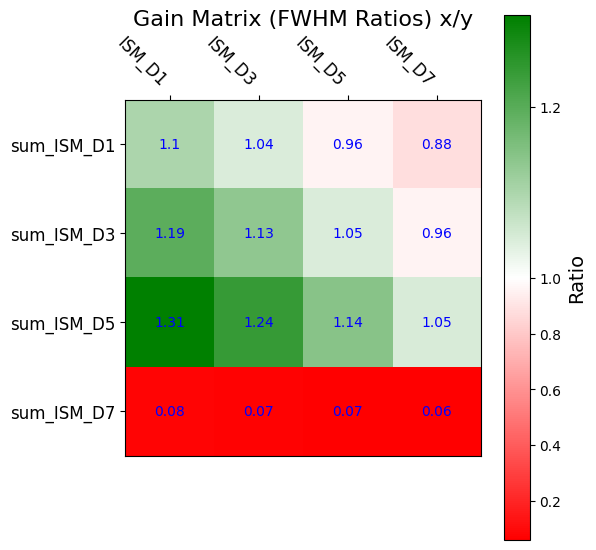

In [181]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap



for index in range(len(result)):
    filterx = ['ISM_D1', 'ISM_D3', 'ISM_D5', 'ISM_D7']
    comparx = {k: result[index][k] for k in filterx if k in result[index]}  # Take the first dictionary from the list
    filtery = ['sum_ISM_D1', 'sum_ISM_D3', 'sum_ISM_D5', 'sum_ISM_D7']
    compary = {k: result[index][k] for k in filtery if k in result[index]}  # Take the first dictionary from the list

    labelsx = list(comparx.keys())
    labelsy = list(compary.keys())

    matrix_guadagno = np.zeros((len(labelsx), len(labelsy)))

    for k, v in enumerate(compary.values()):
        for l, w in enumerate(comparx.values()):
            matrix_guadagno[k, l] = np.round(v / w, 4)
    
    cmap = LinearSegmentedColormap.from_list('red_white_green', ['red', 'white', 'green'])
    try:
        norm = TwoSlopeNorm(vmin=matrix_guadagno.min(), vcenter=1.0, vmax=matrix_guadagno.max())
    except:
        norm = TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=2)

    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(matrix_guadagno,  cmap=cmap, norm=norm)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Ratio', fontsize=14)

    # Set axis labels and ticks


    ax.set_xticks(np.arange(len(labelsx)))
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
    ax.set_yticks(np.arange(len(labelsy)))
    ax.set_xticklabels(labelsx, rotation=-45, ha='right', fontsize=12)
    ax.set_yticklabels(labelsy, fontsize=12)
    #ax.set_xlabel('Compared', fontsize=14)
    #ax.set_ylabel('Reference', fontsize=14)
    ax.set_title('Gain Matrix (FWHM Ratios) x/y', fontsize=16)

    # Annotate values
    for i in range(len(labelsy)):
        for j in range(len(labelsx)):
            ax.text(j, i, f"{np.round(matrix_guadagno[i, j], 2)}", ha="center", va="center", color="blue", fontsize=10)

    plt.tight_layout()
    plt.show()

# ANALISI DEI DATI RACCOLTI DI TUTTI

In [ ]:
ISM_DATAFRAME = pd.read_csv('./images/ISM/ISM_FWHM.csv')
display(ISM_DATAFRAME)

,CENTRAL SPAD,ISM_D1,ISM_D3,ISM_D5,ISM_D7,err CENTAL SPAD,err ISM_D1,err ISM_D3,err ISM_D5,err ISM_D7,FILE,ROI CENTRAL SPAD,ROI ISM_D1,ROI ISM_D3,ROI ISM_D5,ROI ISM_D7
0,6.3148,6.5802,6.6604,6.7281,7.0613,0.3541,0.0695,0.0573,0.1058,0.0998,Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6,2,1,1,1,1
1,8.3770,7.5061,8.4429,8.5378,8.2153,0.3117,0.3179,0.1984,0.2000,0.3522,Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6,8,8,8,8,8
2,5.9062,5.8244,6.7117,6.8140,7.1968,0.3011,0.1378,0.1220,0.1464,0.1421,Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6,9,6,6,5,6
3,1.5091,6.3851,7.2477,6.4147,6.8904,3.0197,0.1809,0.1319,0.1641,0.1510,Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6,10,5,5,6,5
4,6.2867,6.7377,6.8881,6.8801,7.8516,0.2204,0.0896,0.0914,0.0764,0.0701,Qdots_770nm_34mW_FOV5um_64x64_60rip_2msPixel_ROI6,3,3,3,3,3
5,6.1869,4.7278,5.3594,5.9124,6.4039,0.6098,0.2701,0.2092,0.1439,0.1415,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,0,0,0,0,0
6,4.7262,6.7591,3.0401,2.8927,8.0424,0.2665,0.2334,1.1544,1.8083,0.1133,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,1,2,2,2,2
7,3.1869,6.0555,6.6993,7.1997,7.9655,0.5425,0.4862,0.3202,0.2608,0.2444,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,2,3,3,3,3
8,2.8661,6.6842,7.2380,7.6511,8.1165,0.8811,0.3953,0.2385,0.1479,0.1033,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,3,4,4,4,4
9,4.4309,6.3032,6.5933,6.9971,7.6285,0.1765,0.2077,0.1562,0.0931,0.0846,Qdots_770nm_34mW_FOV4um_64x64_100rip_1msPixel_...,4,5,5,5,5


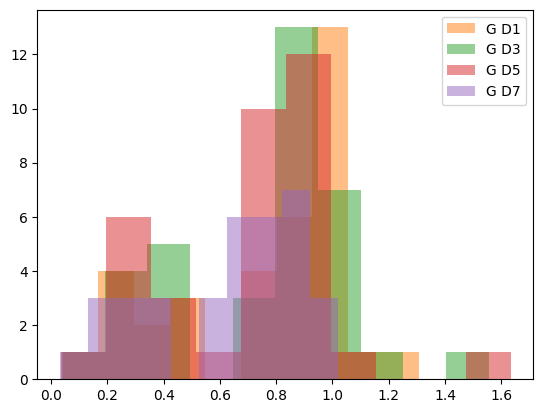

In [ ]:
G_D1 = ISM_DATAFRAME['CENTRAL SPAD'] / ISM_DATAFRAME['ISM_D1']
G_D3 = ISM_DATAFRAME['CENTRAL SPAD'] / ISM_DATAFRAME['ISM_D3']
G_D5 = ISM_DATAFRAME['CENTRAL SPAD'] / ISM_DATAFRAME['ISM_D5']
G_D7 = ISM_DATAFRAME['CENTRAL SPAD'] / ISM_DATAFRAME['ISM_D7']

plt.hist(G_D1, bins=10, alpha=0.5, label='G D1', color='tab:orange')
plt.hist(G_D3, bins=10, alpha=0.5, label='G D3', color='tab:green')
plt.hist(G_D5, bins=10, alpha=0.5, label='G D5', color='tab:red')
plt.hist(G_D7, bins=10, alpha=0.5, label='G D7', color='tab:purple')
plt.legend()
plt.show()

- analizzare ROI 2
- riportare fingerprint
- discorso segnale per correlazioni nella roi 2 (L'ism funziona sofi no)
- mostrare il blinking per confermare scala temporale ( più immagini stessa sequenza temporale)
